In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD

In [2]:
dataset_dir = r"C:\Users\karan\Documents\Intellipaat Python\AI and DL\dataset_cd"
train_dir = dataset_dir + r"\train"
test_dir = dataset_dir + r"\test"

print(train_dir)
print(test_dir)

C:\Users\karan\Documents\Intellipaat Python\AI and DL\dataset_cd\train
C:\Users\karan\Documents\Intellipaat Python\AI and DL\dataset_cd\test


In [3]:
import os

print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))

Train folder exists: True
Test folder exists: True
Train classes: ['cats', 'dogs']
Test classes: ['cats', 'dogs']


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

Found 1536 images belonging to 2 classes.


In [7]:
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 382 images belonging to 2 classes.


In [8]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 718 images belonging to 2 classes.


In [9]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

print("VGG16 loaded successfully!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
VGG16 loaded successfully!


In [10]:
base_model.trainable = False

print("VGG16 layers frozen.")

VGG16 layers frozen.


In [11]:
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,610 (64.14 MB)

 Trainable params: 2,097,922 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(
    learning_rate=0.001,
    momentum=0.9
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [15]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 726s 15s/step - accuracy: 0.8652 - loss: 6.3373 - val_accuracy: 0.9319 - val_loss: 2.3919
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 798s 17s/step - accuracy: 0.8906 - loss: 3.5298 - val_accuracy: 0.9267 - val_loss: 2.2256
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 327s 7s/step - accuracy: 0.9030 - loss: 1.7572 - val_accuracy: 0.9136 - val_loss: 0.6943
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 344s 7s/step - accuracy: 0.9049 - loss: 0.5939 - val_accuracy: 0.9424 - val_loss: 0.2285
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 321s 7s/step - accuracy: 0.9128 - loss: 0.3953 - val_accuracy: 0.9346 - val_loss: 0.2261
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 323s 7s/step - accuracy: 0.9115 - loss: 0.3172 - val_accuracy: 0.9293 - val_loss: 0.1662
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 325s 7s/step - accuracy: 0.9082 - loss: 0.2770 - val_accuracy: 0.9372 - val_loss: 0.1721
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 335s 7s/step - accuracy: 0.9258 - loss: 0.1916 - val_accuracy: 0.9162 -

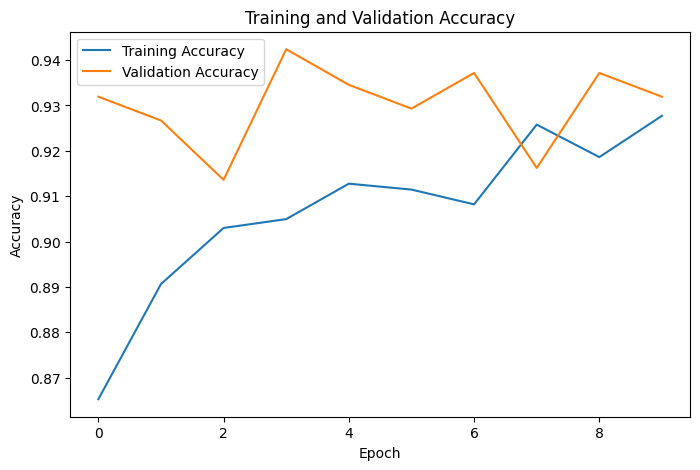

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

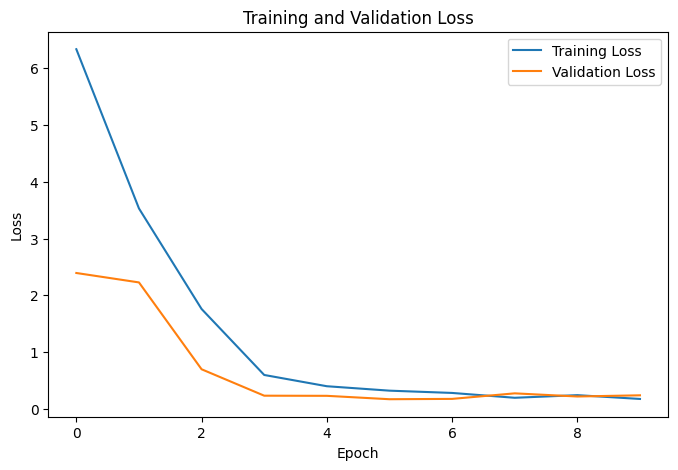

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [18]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

23/23 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - accuracy: 0.9624 - loss: 0.1323
Test Loss: 0.13226190209388733
Test Accuracy: 0.9623955488204956
Test Accuracy: 96.24%


In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):

    img = image.load_img(
        img_path,
        target_size=(150, 150)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)

    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class] * 100

    class_labels = {
        value: key
        for key, value in train_generator.class_indices.items()
    }

    predicted_label = class_labels[predicted_class]

    print("Predicted Class:", predicted_label)
    print(f"Confidence: {confidence:.2f}%")

    return predicted_label, confidence

In [25]:
predict_image(r"C:\Users\karan\Documents\Intellipaat Python\AI and DL\dataset_cd\test\cats\cat.2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
Predicted Class: cats
Confidence: 100.00%


('cats', np.float32(100.0))